# Ablación Sprint 3 — Componentes del GA

Experimentos de **ablación** según la definición del profesor:  
> *"Change ONLY ONE component, keep split / seed / metric identical."*

Cada experimento cambia **un único** componente respecto a la **configuración de referencia**,
manteniendo viga, semillas, `pop_size` y `n_gen` idénticos.

| Experimento | Componente cambiado | Hipótesis |
|---|---|---|
| `REF` | — (baseline) | — |
| `ABL_REPAIR` | Operador de reparación desactivado | Sin reparar: más violaciones duras → fitness peor, menor factibilidad |
| `ABL_ELITE` | `N_ELITE = 0` (sin elitismo) | Pérdida de mejores soluciones entre generaciones → mayor varianza |
| `ABL_ES` | `early_stop_pat = 9999` (sin parada temprana) | Más iteraciones pero resultado final similar al REF |
| `ABL_TK2` | `tournament_k = 2` (baja presión de selección) | Mayor diversidad, convergencia más lenta |
| `ABL_TK8` | `tournament_k = 8` (alta presión de selección) | Convergencia rápida pero posible premature convergence |

## MLOps ligero
- Experimentos logueados en **MLflow** (params + metrics + artefactos)
- Reproducible: `jupyter nbconvert --to notebook --execute notebooks/ablacion_sprint3.ipynb`
- Artefactos: `notebooks/output/ablacion_sprint3/`

In [1]:
%matplotlib inline
import sys, os, json, time
from datetime import datetime
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path(os.getcwd()).parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from beam_n import BeamGANSpans, ensure_joints
import beam_n.beam_ga_n as _bga_module   # para monkey-patch N_ELITE

try:
    import mlflow
    MLFLOW_AVAILABLE = True
    print(f'MLflow {mlflow.__version__} OK')
except ImportError:
    MLFLOW_AVAILABLE = False
    print('MLflow no instalado -- pip install mlflow -- tracking deshabilitado')

print(f'ROOT: {ROOT}')

MLflow no instalado -- pip install mlflow -- tracking deshabilitado
ROOT: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl


In [2]:
# ── Viga de referencia ─────────────────────────────────────────────────────
DATA_DIR  = ROOT / 'data'
BEAM_FILE = DATA_DIR / 'beam_viga_3_tramos.json'   # 3 tramos: mayor espacio de busqueda

# ── Semillas fijas (NUNCA cambiar entre ablaciones) ────────────────────────
SEEDS = [42, 123, 7]

# ── Hiperparametros FIJOS para TODAS las ablaciones ───────────────────────
POP             = 100
N_GEN           = 100
EARLY_STOP_BASE =  30   # activa early stopping antes de agotar N_GEN
TK_BASE         =   3
N_ELITE_BASE    =   5

# ── Salida ─────────────────────────────────────────────────────────────────
OUT_DIR = ROOT / 'notebooks' / 'output' / 'ablacion_sprint3'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── MLflow ─────────────────────────────────────────────────────────────────
MLFLOW_EXP = 'ablacion_sprint3_ga'
if MLFLOW_AVAILABLE:
    mlflow.set_experiment(MLFLOW_EXP)
    print(f'MLflow experiment: {MLFLOW_EXP}')

print(f'Beam  : {BEAM_FILE.name}')
print(f'Seeds : {SEEDS}')
print(f'GA    : pop={POP}  n_gen={N_GEN}  early_stop={EARLY_STOP_BASE}  tk={TK_BASE}  elite={N_ELITE_BASE}')
print(f'Salida: {OUT_DIR}')

Beam  : beam_viga_3_tramos.json
Seeds : [42, 123, 7]
GA    : pop=100  n_gen=100  early_stop=30  tk=3  elite=5
Salida: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl\notebooks\output\ablacion_sprint3


In [3]:
with open(BEAM_FILE, encoding='utf-8') as f:
    BEAM = json.load(f)
ensure_joints(BEAM)

print(f"Viga cargada : id={BEAM['id']},  n_spans={BEAM['n_spans']}")
print(f"  b={BEAM['inputs']['b_m']} m,  h={BEAM['inputs']['h_m']} m,  "
      f"fc={BEAM['inputs']['fc_kg_cm2']} kg/cm2")
for i, sp in enumerate(BEAM['spans']):
    print(f"  T{i+1}: L={sp['L_m']:.2f} m  [{sp['x0']:.2f} -> {sp['x1']:.2f} m]")

Viga cargada : id=18+17+16,  n_spans=3
  b=0.25 m,  h=0.55 m,  fc=210.0 kg/cm2
  T1: L=5.73 m  [0.00 -> 5.73 m]
  T2: L=5.45 m  [5.73 -> 11.18 m]
  T3: L=2.75 m  [11.18 -> 13.93 m]


---
## Definición de configuraciones

Cada configuración cambia **exactamente un** campo respecto a `REF`.  
El resto de parámetros (`pop`, `n_gen`, `seeds`, `beam`) permanece constante.

In [4]:
ABLATION_CONFIGS = [
    {
        'name'        : 'REF',
        'desc'        : 'Configuracion de referencia',
        'use_repair'  : True,
        'n_elite'     : N_ELITE_BASE,
        'early_stop'  : EARLY_STOP_BASE,
        'tournament_k': TK_BASE,
    },
    {
        'name'        : 'ABL_REPAIR',
        'desc'        : 'Sin reparacion del cromosoma',
        'use_repair'  : False,          # <-- UNICO cambio
        'n_elite'     : N_ELITE_BASE,
        'early_stop'  : EARLY_STOP_BASE,
        'tournament_k': TK_BASE,
    },
    {
        'name'        : 'ABL_ELITE',
        'desc'        : 'Sin elitismo (N_ELITE=0)',
        'use_repair'  : True,
        'n_elite'     : 0,              # <-- UNICO cambio
        'early_stop'  : EARLY_STOP_BASE,
        'tournament_k': TK_BASE,
    },
    {
        'name'        : 'ABL_ES',
        'desc'        : 'Sin early stopping (pat=9999)',
        'use_repair'  : True,
        'n_elite'     : N_ELITE_BASE,
        'early_stop'  : 9999,           # <-- UNICO cambio
        'tournament_k': TK_BASE,
    },
    {
        'name'        : 'ABL_TK2',
        'desc'        : 'Baja presion de seleccion (k=2)',
        'use_repair'  : True,
        'n_elite'     : N_ELITE_BASE,
        'early_stop'  : EARLY_STOP_BASE,
        'tournament_k': 2,              # <-- UNICO cambio
    },
    {
        'name'        : 'ABL_TK8',
        'desc'        : 'Alta presion de seleccion (k=8)',
        'use_repair'  : True,
        'n_elite'     : N_ELITE_BASE,
        'early_stop'  : EARLY_STOP_BASE,
        'tournament_k': 8,              # <-- UNICO cambio
    },
]

for cfg in ABLATION_CONFIGS:
    diff = [k for k in ('use_repair', 'n_elite', 'early_stop', 'tournament_k')
            if cfg[k] != ABLATION_CONFIGS[0][k]]
    tag = f'  <- cambia: {", ".join(diff)}' if diff else '  <- REFERENCIA'
    print(f"  {cfg['name']:<14}  {cfg['desc']}{tag}")

  REF             Configuracion de referencia  <- REFERENCIA
  ABL_REPAIR      Sin reparacion del cromosoma  <- cambia: use_repair
  ABL_ELITE       Sin elitismo (N_ELITE=0)  <- cambia: n_elite
  ABL_ES          Sin early stopping (pat=9999)  <- cambia: early_stop
  ABL_TK2         Baja presion de seleccion (k=2)  <- cambia: tournament_k
  ABL_TK8         Alta presion de seleccion (k=8)  <- cambia: tournament_k


---
## Funciones de ejecución

In [5]:
def run_one(beam, seed, cfg):
    """Ejecuta UNA corrida del GA con la configuracion de ablacion dada.

    Aplica monkey-patches temporales para N_ELITE y use_repair;
    siempre restaura el estado original al terminar.
    """
    # -- 1. Patch N_ELITE en el modulo (usado por run() directamente) ------
    _orig_elite = _bga_module.N_ELITE
    _bga_module.N_ELITE = cfg['n_elite']

    try:
        ga = BeamGANSpans(
            beam,
            pop_size     = POP,
            n_gen        = N_GEN,
            tournament_k = cfg['tournament_k'],
            seed         = seed,
        )
        # early_stop_pat es atributo de instancia => se puede sobreescribir
        ga.early_stop_pat = cfg['early_stop']

        # -- 2. Patch _repair en la instancia (solo si se ablata) ----------
        if not cfg['use_repair']:
            ga._repair = lambda z: z.copy()   # operador identidad

        t0 = time.time()
        result = ga.run()
        elapsed = time.time() - t0

    finally:
        # -- 3. Restaurar N_ELITE siempre (aun si hay excepcion) -----------
        _bga_module.N_ELITE = _orig_elite

    top     = result['top3'][0]
    n_zones = ga.n_zones

    return {
        'config'       : cfg['name'],
        'seed'         : seed,
        'weight_kg'    : round(top['total_weight_kg'], 2),
        'fitness'      : round(top['fitness'], 4),
        'feasible'     : top['feasible'],
        'zones_ok'     : top['zones_ok'],
        'n_zones'      : n_zones,
        'gens_run'     : result['generations_run'],
        'early_stop'   : result['early_stop'],
        'time_s'       : round(elapsed, 1),
        'violations'   : top['violations'],
        'history_best' : result['history_best'],
        'history_mean' : result['history_mean'],
    }


def run_ablation(cfg, beam=None, seeds=None):
    """Corre una ablacion sobre todas las semillas y registra en MLflow."""
    if beam  is None: beam  = BEAM
    if seeds is None: seeds = SEEDS

    sep = '=' * 62
    print(f'\n{sep}')
    print(f'  [{cfg["name"]}]  {cfg["desc"]}')
    print(f'  repair={cfg["use_repair"]}  elite={cfg["n_elite"]}  '
          f'es={cfg["early_stop"]}  tk={cfg["tournament_k"]}')
    print(sep)

    runs = []
    for seed in seeds:
        print(f'  seed={seed} ... ', end='', flush=True)
        rec = run_one(beam, seed, cfg)
        runs.append(rec)
        print(f"W={rec['weight_kg']:.2f}kg  feas={rec['feasible']}  "
              f"zones={rec['zones_ok']}/{rec['n_zones']}  "
              f"gens={rec['gens_run']}  t={rec['time_s']}s")

    W     = [r['weight_kg'] for r in runs]
    feas  = [int(r['feasible']) for r in runs]
    gens  = [r['gens_run']   for r in runs]
    tsecs = [r['time_s']     for r in runs]

    summary = {
        'config'       : cfg['name'],
        'desc'         : cfg['desc'],
        'use_repair'   : cfg['use_repair'],
        'n_elite'      : cfg['n_elite'],
        'early_stop'   : cfg['early_stop'],
        'tournament_k' : cfg['tournament_k'],
        'W_mean'       : round(np.mean(W),        2),
        'W_std'        : round(np.std(W),         2),
        'feas_pct'     : round(np.mean(feas)*100, 1),
        'gens_mean'    : round(np.mean(gens),     1),
        'time_mean'    : round(np.mean(tsecs),    1),
        'runs'         : runs,
    }

    # -- MLflow logging por configuracion ----------------------------------
    if MLFLOW_AVAILABLE:
        with mlflow.start_run(run_name=cfg['name']):
            mlflow.log_params({
                'config'       : cfg['name'],
                'pop_size'     : POP,
                'n_gen'        : N_GEN,
                'use_repair'   : cfg['use_repair'],
                'n_elite'      : cfg['n_elite'],
                'early_stop'   : cfg['early_stop'],
                'tournament_k' : cfg['tournament_k'],
                'seeds'        : str(seeds),
                'beam_id'      : str(beam['id']),
                'n_spans'      : beam['n_spans'],
            })
            mlflow.log_metrics({
                'W_mean_kg'    : summary['W_mean'],
                'W_std_kg'     : summary['W_std'],
                'feas_pct'     : summary['feas_pct'],
                'gens_mean'    : summary['gens_mean'],
                'time_mean_s'  : summary['time_mean'],
            })
            # CSV de detalle por corrida
            detail_csv = str(OUT_DIR / f'{cfg["name"]}_detalle.csv')
            pd.DataFrame([{
                'seed'      : r['seed'],
                'weight_kg' : r['weight_kg'],
                'feasible'  : r['feasible'],
                'zones_ok'  : r['zones_ok'],
                'gens_run'  : r['gens_run'],
                'time_s'    : r['time_s'],
            } for r in runs]).to_csv(detail_csv, index=False)
            mlflow.log_artifact(detail_csv)

    return summary


print('run_one() y run_ablation() definidas.')

run_one() y run_ablation() definidas.


---
## Ejecución de experimentos

> Esta celda tarda varios minutos (6 configs × 3 seeds × ~30–100 generaciones).  
> Tiempo estimado con pop=100, n_gen=100 sobre viga 3-tramos: **~15–25 min**.

In [6]:
all_results = []

for cfg in ABLATION_CONFIGS:
    summary = run_ablation(cfg)
    all_results.append(summary)

print(f'\n\u2713 {len(all_results)} ablaciones completadas.')


  [REF]  Configuracion de referencia
  repair=True  elite=5  es=30  tk=3
  seed=42 ...   Gen   1/100 | best=1971.16 | mean=73522.72 | HoF=211.83kg (18/18 OK) | sin mejora= 0 | 1.0s
  Gen   2/100 | best=378.69 | mean=48276.32 | HoF=245.44kg (18/18 OK) | sin mejora= 0 | 2.2s
  Gen   5/100 | best=271.68 | mean=59659.32 | HoF=241.51kg (18/18 OK) | sin mejora= 0 | 6.1s
  Gen  10/100 | best=271.68 | mean=54648.04 | HoF=241.51kg (18/18 OK) | sin mejora= 5 | 12.7s
  Gen  15/100 | best=271.68 | mean=53073.01 | HoF=241.51kg (18/18 OK) | sin mejora=10 | 19.0s
  Gen  20/100 | best=271.68 | mean=52579.49 | HoF=241.51kg (18/18 OK) | sin mejora=15 | 25.1s
  Gen  25/100 | best=271.68 | mean=49861.14 | HoF=241.51kg (18/18 OK) | sin mejora=20 | 31.5s
  Gen  30/100 | best=271.68 | mean=37859.52 | HoF=241.51kg (18/18 OK) | sin mejora=25 | 37.3s
  [Reinicio #1] Gen 30 -- reemplazados 50 (37.3s)
  Gen  35/100 | best=271.68 | mean=47553.62 | HoF=241.51kg (18/18 OK) | sin mejora=30 | 43.4s
  [Early stop] Gen

---
## Tabla comparativa de resultados

In [7]:
def print_tabla(results):
    hdr = (f"{'Config':<14} {'W_mean(kg)':>10} {'W_std':>7} "
           f"{'Feas%':>6} {'Gens_mean':>10} {'t_mean(s)':>10}  Desc")
    print(hdr)
    print('─' * 85)
    ref_W = next(r['W_mean'] for r in results if r['config'] == 'REF')
    for r in results:
        delta = r['W_mean'] - ref_W
        flag  = '  <- REF' if r['config'] == 'REF' else f'  ({delta:+.2f} kg vs REF)'
        print(f"{r['config']:<14} {r['W_mean']:>10.2f} {r['W_std']:>7.2f} "
              f"{r['feas_pct']:>5.1f}% {r['gens_mean']:>10.1f} {r['time_mean']:>10.1f}"
              f"  {r['desc']}{flag}")

print_tabla(all_results)

Config         W_mean(kg)   W_std  Feas%  Gens_mean  t_mean(s)  Desc
─────────────────────────────────────────────────────────────────────────────────────
REF                245.58    5.75 100.0%       43.0       52.7  Configuracion de referencia  <- REF
ABL_REPAIR         249.64    5.75 100.0%       44.3       54.5  Sin reparacion del cromosoma  (+4.06 kg vs REF)
ABL_ELITE          253.71    0.00 100.0%       47.0       62.5  Sin elitismo (N_ELITE=0)  (+8.13 kg vs REF)
ABL_ES             249.64    5.75 100.0%      100.0      124.6  Sin early stopping (pat=9999)  (+4.06 kg vs REF)
ABL_TK2            253.71    0.00 100.0%       55.0       79.3  Baja presion de seleccion (k=2)  (+8.13 kg vs REF)
ABL_TK8            245.58    5.75 100.0%       32.3       38.8  Alta presion de seleccion (k=8)  (+0.00 kg vs REF)


---
## Curvas de convergencia por ablación

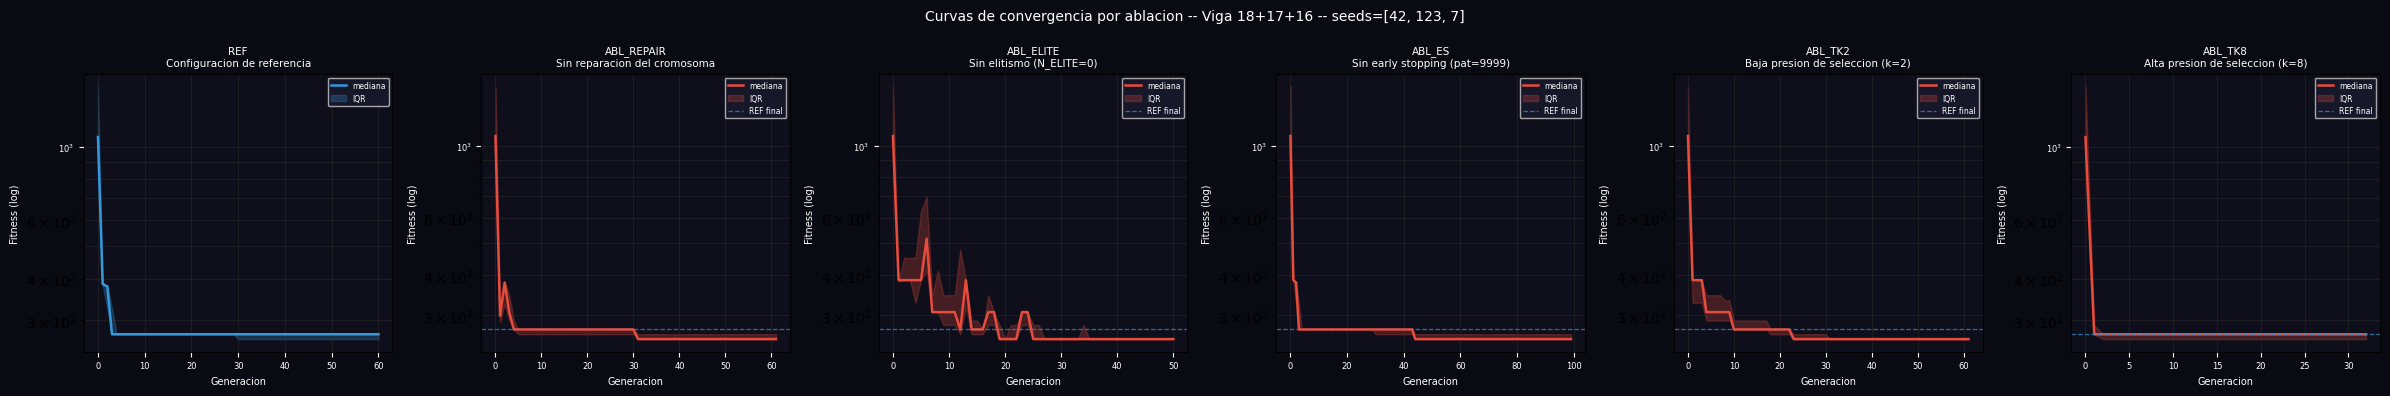

Guardado: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl\notebooks\output\ablacion_sprint3\conv_ablaciones.png


In [8]:
def plot_convergencia_ablaciones(results, out_dir):
    n   = len(results)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4), squeeze=False)
    fig.patch.set_facecolor('#0a0a12')

    # Valor final de REF como linea de referencia
    ref_r  = next(r for r in results if r['config'] == 'REF')
    ref_med_final = np.median(
        [r['history_best'][-1] for r in ref_r['runs']])

    for col, r in enumerate(results):
        ax  = axes[0][col]
        ax.set_facecolor('#0f0f1b')
        runs = r['runs']

        max_g = max(len(run['history_best']) for run in runs)
        def pad(h):
            return h + [h[-1]] * (max_g - len(h))

        arr  = np.array([pad(run['history_best']) for run in runs])
        gens = np.arange(max_g)
        med  = np.median(arr, axis=0)
        lo   = np.percentile(arr, 25, axis=0)
        hi   = np.percentile(arr, 75, axis=0)

        color = '#3498db' if r['config'] == 'REF' else '#e74c3c'
        ax.semilogy(gens, med, color=color, lw=1.8, label='mediana')
        ax.fill_between(gens, lo, hi, color=color, alpha=0.25, label='IQR')

        if r['config'] != 'REF':
            ax.axhline(ref_med_final, color='#3498db', lw=0.9,
                       ls='--', alpha=0.7, label='REF final')

        ax.set_title(f"{r['config']}\n{r['desc']}",
                     color='white', fontsize=7.5)
        ax.set_xlabel('Generacion', color='white', fontsize=7)
        ax.set_ylabel('Fitness (log)', color='white', fontsize=7)
        ax.tick_params(colors='white', labelsize=6)
        ax.grid(True, which='both', color='#333', alpha=0.4)
        ax.legend(fontsize=5.5, facecolor='#1a1a2e', labelcolor='white')

    fig.suptitle(
        f"Curvas de convergencia por ablacion -- Viga {BEAM['id']} -- seeds={SEEDS}",
        color='white', fontsize=10)
    plt.tight_layout()

    path = out_dir / 'conv_ablaciones.png'
    plt.savefig(path, dpi=130, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Guardado: {path}')
    return str(path)


conv_path = plot_convergencia_ablaciones(all_results, OUT_DIR)

---
## Comparación de métricas agregadas

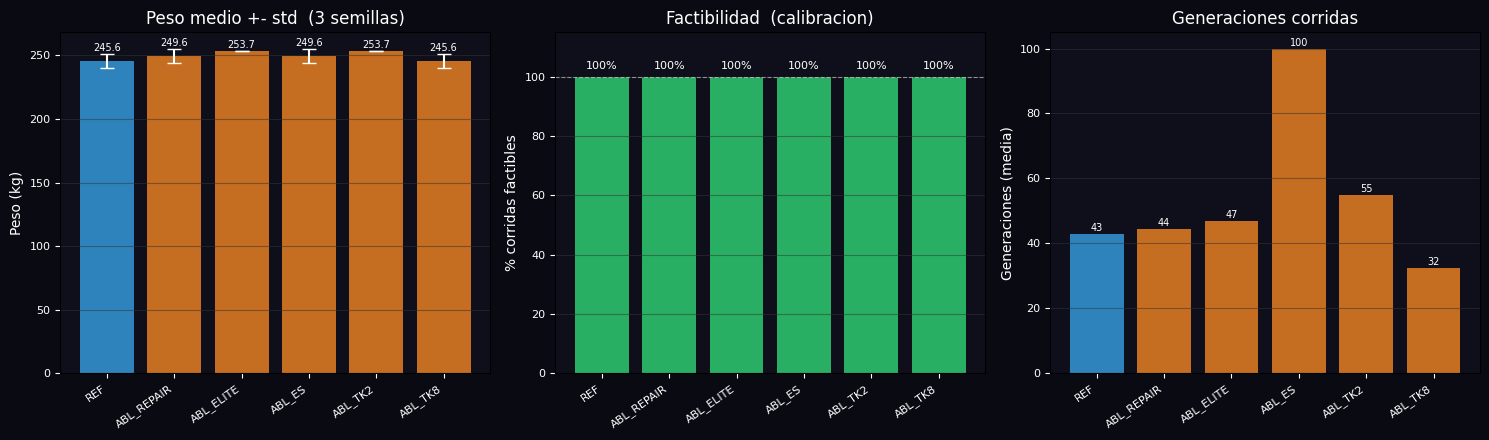

Guardado: c:\Users\EFRAIN\Documents\UNIVERSIDAD\UNI\TESIS\repositorio_tesis II\beam_drl\notebooks\output\ablacion_sprint3\comparacion_ablaciones.png


In [9]:
def plot_comparacion(results, out_dir):
    names  = [r['config']   for r in results]
    W_mean = [r['W_mean']   for r in results]
    W_std  = [r['W_std']    for r in results]
    feas   = [r['feas_pct'] for r in results]
    gens   = [r['gens_mean'] for r in results]

    x      = np.arange(len(names))
    colors = ['#3498db' if n == 'REF' else '#e67e22' for n in names]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.patch.set_facecolor('#0a0a12')

    for ax in axes:
        ax.set_facecolor('#0f0f1b')
        ax.tick_params(colors='white', labelsize=8)
        ax.set_xticks(x)
        ax.set_xticklabels(names, rotation=35, ha='right',
                           color='white', fontsize=8)
        ax.grid(True, axis='y', color='#333', alpha=0.5)

    # ── Peso medio +- std ──────────────────────────────────────────────────
    bars = axes[0].bar(x, W_mean, yerr=W_std, color=colors, alpha=0.85,
                       error_kw=dict(ecolor='white', capsize=5, lw=1.5))
    axes[0].set_ylabel('Peso (kg)', color='white')
    axes[0].set_title('Peso medio +- std  (3 semillas)', color='white')
    for bar, v, s in zip(bars, W_mean, W_std):
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + s + 0.3,
                     f'{v:.1f}', ha='center', va='bottom',
                     color='white', fontsize=7)

    # ── Factibilidad ───────────────────────────────────────────────────────
    c2 = ['#2ecc71' if p == 100 else '#e74c3c' if p == 0 else '#f39c12'
          for p in feas]
    axes[1].bar(x, feas, color=c2, alpha=0.85)
    axes[1].axhline(100, color='white', lw=0.8, ls='--', alpha=0.5)
    axes[1].set_ylim(0, 115)
    axes[1].set_ylabel('% corridas factibles', color='white')
    axes[1].set_title('Factibilidad  (calibracion)', color='white')
    for xi, v in zip(x, feas):
        axes[1].text(xi, v + 2, f'{v:.0f}%', ha='center', va='bottom',
                     color='white', fontsize=8)

    # ── Generaciones corridas ──────────────────────────────────────────────
    axes[2].bar(x, gens, color=colors, alpha=0.85)
    axes[2].set_ylabel('Generaciones (media)', color='white')
    axes[2].set_title('Generaciones corridas', color='white')
    for xi, v in zip(x, gens):
        axes[2].text(xi, v + 0.3, f'{v:.0f}', ha='center', va='bottom',
                     color='white', fontsize=7)

    plt.tight_layout()
    path = out_dir / 'comparacion_ablaciones.png'
    plt.savefig(path, dpi=130, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print(f'Guardado: {path}')
    return str(path)


comp_path = plot_comparacion(all_results, OUT_DIR)

---
## Exportar CSV y artefactos MLflow

In [10]:
# ── Tabla resumen CSV ─────────────────────────────────────────────────────
rows = [{
    'config'       : r['config'],
    'desc'         : r['desc'],
    'use_repair'   : r['use_repair'],
    'n_elite'      : r['n_elite'],
    'early_stop'   : r['early_stop'],
    'tournament_k' : r['tournament_k'],
    'W_mean_kg'    : r['W_mean'],
    'W_std_kg'     : r['W_std'],
    'feas_pct'     : r['feas_pct'],
    'gens_mean'    : r['gens_mean'],
    'time_mean_s'  : r['time_mean'],
} for r in all_results]

df = pd.DataFrame(rows)
csv_path = str(OUT_DIR / 'ablacion_sprint3_tabla.csv')
df.to_csv(csv_path, index=False)
print(df.to_string(index=False))

# ── Log JSON con timestamp ────────────────────────────────────────────────
ts       = datetime.now().isoformat(timespec='seconds')
log_path = str(OUT_DIR / f'log_ablacion_{ts.replace(":", "-")}.json')
log_data = {
    'timestamp'   : ts,
    'beam_id'     : BEAM['id'],
    'n_spans'     : BEAM['n_spans'],
    'seeds'       : SEEDS,
    'pop'         : POP,
    'n_gen'       : N_GEN,
    'early_stop_base': EARLY_STOP_BASE,
    'results'     : [
        {k: v for k, v in r.items() if k != 'runs'}
        for r in all_results
    ],
}
with open(log_path, 'w', encoding='utf-8') as f:
    json.dump(log_data, f, indent=2, ensure_ascii=False)

print(f'\nCSV : {csv_path}')
print(f'Log : {log_path}')

# ── Loguear artefactos globales en MLflow ─────────────────────────────────
if MLFLOW_AVAILABLE:
    with mlflow.start_run(run_name='ablacion_sprint3_summary'):
        mlflow.log_params({
            'beam_id' : str(BEAM['id']),
            'n_spans' : BEAM['n_spans'],
            'pop'     : POP,
            'n_gen'   : N_GEN,
            'seeds'   : str(SEEDS),
        })
        mlflow.log_artifact(conv_path)
        mlflow.log_artifact(comp_path)
        mlflow.log_artifact(csv_path)
        mlflow.log_artifact(log_path)
    print('Artefactos globales logueados en MLflow.')

print('\nComando reproducible:')
print('  jupyter nbconvert --to notebook --execute '
      'notebooks/ablacion_sprint3.ipynb')

    config                            desc  use_repair  n_elite  early_stop  tournament_k  W_mean_kg  W_std_kg  feas_pct  gens_mean  time_mean_s
       REF     Configuracion de referencia        True        5          30             3     245.58      5.75     100.0       43.0         52.7
ABL_REPAIR    Sin reparacion del cromosoma       False        5          30             3     249.64      5.75     100.0       44.3         54.5
 ABL_ELITE        Sin elitismo (N_ELITE=0)        True        0          30             3     253.71      0.00     100.0       47.0         62.5
    ABL_ES   Sin early stopping (pat=9999)        True        5        9999             3     249.64      5.75     100.0      100.0        124.6
   ABL_TK2 Baja presion de seleccion (k=2)        True        5          30             2     253.71      0.00     100.0       55.0         79.3
   ABL_TK8 Alta presion de seleccion (k=8)        True        5          30             8     245.58      5.75     100.0       32.

---
## Análisis de resultados

### Interpretación por ablación

| Ablación | Efecto esperado | Métrica clave |
|---|---|---|
| `ABL_REPAIR` | Sin reparar: restricciones duras violadas → penalizaciones activas → fitness alto, factibilidad baja | `feas_pct` < REF |
| `ABL_ELITE` | Sin preservar los mejores: la evolución puede perder soluciones ya encontradas → mayor `W_std` | `W_std` > REF |
| `ABL_ES` | Sin parada temprana: el GA corre todas las `n_gen` generaciones → más tiempo, resultado final similar | `gens_mean` = N_GEN, `W_mean` ≈ REF |
| `ABL_TK2` | Menor presión de selección: más diversidad, convergencia más lenta | `gens_mean` > REF |
| `ABL_TK8` | Mayor presión: converge rápido (early stop pronto) pero puede caer en mínimos locales | `gens_mean` < REF |

### Criterio de significancia

Una ablación es **significativa** si su `W_mean` difiere del REF en más de `W_std_REF`,
o si su `feas_pct` es inferior al 100%.



In [11]:
# Genera el bloque tabular para pegar directamente en LaTeX
print('% --- Tabla ablacion sprint3 para LaTeX ---')
print(df[['config', 'W_mean_kg', 'W_std_kg', 'feas_pct', 'gens_mean', 'time_mean_s']]
      .rename(columns={
          'config'      : 'Experimento',
          'W_mean_kg'   : r'$\bar{W}$ (kg)',
          'W_std_kg'    : r'$\sigma_W$ (kg)',
          'feas_pct'    : 'Feas. (\%)',
          'gens_mean'   : r'$\bar{G}$',
          'time_mean_s' : r'$\bar{t}$ (s)',
      })
      .to_latex(index=False, float_format='%.2f',
                escape=False))

% --- Tabla ablacion sprint3 para LaTeX ---


<>:8: SyntaxWarning: invalid escape sequence '\%'
<>:8: SyntaxWarning: invalid escape sequence '\%'
C:\Users\EFRAIN\AppData\Local\Temp\ipykernel_41364\3036975050.py:8: SyntaxWarning: invalid escape sequence '\%'
  'feas_pct'    : 'Feas. (\%)',


\begin{tabular}{lrrrrr}
\toprule
Experimento & $\bar{W}$ (kg) & $\sigma_W$ (kg) & Feas. (\%) & $\bar{G}$ & $\bar{t}$ (s) \\
\midrule
REF & 245.58 & 5.75 & 100.00 & 43.00 & 52.70 \\
ABL_REPAIR & 249.64 & 5.75 & 100.00 & 44.30 & 54.50 \\
ABL_ELITE & 253.71 & 0.00 & 100.00 & 47.00 & 62.50 \\
ABL_ES & 249.64 & 5.75 & 100.00 & 100.00 & 124.60 \\
ABL_TK2 & 253.71 & 0.00 & 100.00 & 55.00 & 79.30 \\
ABL_TK8 & 245.58 & 5.75 & 100.00 & 32.30 & 38.80 \\
\bottomrule
\end{tabular}

